In [2]:
import sys
import os
sys.path.append('../')
sys.path.append("../../")

import numpy as np
import matplotlib.pyplot as plt
import os
from pydicom import dcmread

from types import MappingProxyType
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"

from pydose_rt.data import MachineConfig
from models.layers import *
from models.utils.data import DataGenerator
from models.utils.plotting import *
from models.utils.kernel import *

/home/bolo/anaconda3/envs/autoplan/lib/python3.9/site-packages/pydantic/_internal/_generate_schema.py:404: UserWarning: <built-in function array> is not a Python type (it may be an instance of an object), Pydantic will allow any object with no validation since we cannot even enforce that the input is an instance of the given type. To get rid of this error wrap the type with `pydantic.SkipValidation`.
  warn(
2025-08-26 15:37:27.432819: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-26 15:37:27.472017: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-26 15:37:28.108325: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [52]:
config_10 = MachineConfig(ct_array_shape=(100, 100, 100), resolution=(0.5, 0.5, 0.5), field_size=(10, 10), number_of_leaf_pairs=60, tpr_20_10=0.72, number_of_cps=1, iso_center=(15.0, 0.0, 0.0))
x_ct = 0.0 * np.expand_dims(np.ones(config_10.ct_array_shape), 0)
y_mlc = np.zeros((1, 2, config_10.number_of_cps, config_10.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
mus = 1.3 * np.ones((1, config_10.number_of_cps), dtype=np.float32)
dose_layer = AccumulateDose3DLayer(config_10, 99)
dose_10 = dose_layer(torch.tensor(x_ct, dtype=torch.float32, device=device), torch.tensor(y_mlc, dtype=torch.float32, device=device), torch.tensor(mus, dtype=torch.float32, device=device)).cpu().detach().numpy()


In [53]:
config_20 = MachineConfig(ct_array_shape=(100, 100, 100), resolution=(0.5, 0.5, 0.5), field_size=(10, 10), number_of_leaf_pairs=60, tpr_20_10=0.72, number_of_cps=1, iso_center=(5.0, 0.0, 0.0))
x_ct = 0.0 * np.expand_dims(np.ones(config_20.ct_array_shape), 0)
y_mlc = np.zeros((1, 2, config_20.number_of_cps, config_20.number_of_leaf_pairs))
y_mlc[:, 0, :, :] = 0.5
y_mlc[:, 1, :, :] = 1.0
mus = 1.3 * np.ones((1, config_20.number_of_cps), dtype=np.float32)
dose_layer = AccumulateDose3DLayer(config_20, 99)
dose_20 = dose_layer(torch.tensor(x_ct, dtype=torch.float32, device=device), torch.tensor(y_mlc, dtype=torch.float32, device=device), torch.tensor(mus, dtype=torch.float32, device=device)).cpu().detach().numpy()



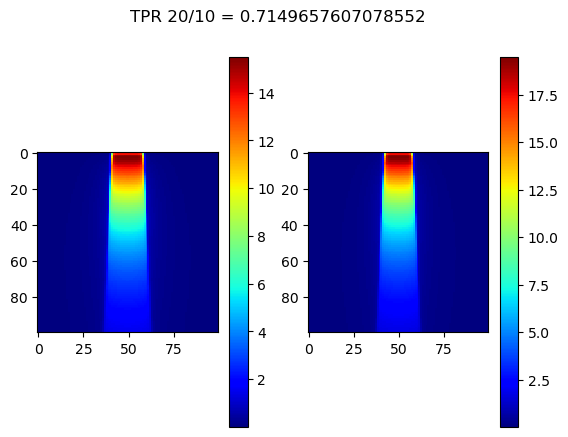

: 

In [ ]:

plt.suptitle(f"TPR 20/10 = {dose_20[0, 40, 50, 50] / dose_10[0, 20, 50, 50]}")
plt.subplot(121)
plt.imshow(dose_10[0, :, :, 50], cmap='jet', vmin=np.min(dose_10), vmax=np.max(dose_10), interpolation='nearest')
plt.colorbar()
plt.subplot(122)
plt.imshow(dose_20[0, :, :, 50], cmap='jet', vmin=np.min(dose_20), vmax=np.max(dose_20), interpolation='nearest')
plt.colorbar()
plt.show()